In [1]:
import seaborn as sns
import pandas as pd

# Load Titanic dataset ONCE
df = sns.load_dataset("titanic")

# Immediately save the raw loaded dataset
df.to_csv("titanic.csv", index=False)

print("Titanic dataset loaded and saved successfully.")
print("Shape:", df.shape)

Titanic dataset loaded and saved successfully.
Shape: (891, 15)


In [2]:
# Basic dataset profiling

print("=== DATASET INFO ===")
df.info()

print("\n=== DESCRIPTIVE STATISTICS ===")
display(df.describe())

print("\n=== DATASET SHAPE ===")
print(df.shape)

print("\n=== FIRST 5 ROWS ===")
display(df.head())

=== DATASET INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB

=== DESCRIPTIVE STATISTICS ===


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



=== DATASET SHAPE ===
(891, 15)

=== FIRST 5 ROWS ===


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Missing-value analysis

missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

# Show only columns that contain missing values
missing_summary = missing_summary[missing_summary["Missing Count"] > 0]

print("=== MISSING VALUE SUMMARY ===")
display(missing_summary)

=== MISSING VALUE SUMMARY ===


,Missing Count,Missing Percentage
age,177,19.865320
embarked,2,0.224467
deck,688,77.216611
embark_town,2,0.224467


In [4]:
# Apply missing-value treatment according to the assignment thresholds

cleaned_df = df.copy()

# 1. Drop rows with missing values in columns below 5% missingness
cleaned_df = cleaned_df.dropna(subset=["embarked", "embark_town"])

# 2. Impute age because it has 5%–30% missingness
age_median = cleaned_df["age"].median()
cleaned_df["age"] = cleaned_df["age"].fillna(age_median)

# 3. Drop deck because it has more than 30% missingness
cleaned_df = cleaned_df.drop(columns=["deck"])

print("Original shape:", df.shape)
print("Cleaned shape:", cleaned_df.shape)
print("\nRemaining missing values:")
display(cleaned_df.isnull().sum())

Original shape: (891, 15)
Cleaned shape: (889, 14)

Remaining missing values:


survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

## Missing-Value Handling

The raw Titanic dataset contained missing values in four columns:

| Column | Missing Count | Missing Percentage | Treatment |
|---|---:|---:|---|
| `age` | 177 | 19.8653% | Median imputation |
| `embarked` | 2 | 0.2245% | Drop rows |
| `deck` | 688 | 77.2166% | Drop column |
| `embark_town` | 2 | 0.2245% | Drop rows |

### Justification

- `age` had 19.8653% missing values, which falls within the 5%–30% range. Therefore, missing ages were replaced using the median age.
- `embarked` had only 0.2245% missing values, which is below 5%, so the affected rows were dropped.
- `embark_town` had only 0.2245% missing values, which is below 5%, so the affected rows were dropped.
- `deck` had 77.2166% missing values, which is above 30%. Therefore, the column was dropped because such a high level of missingness would provide limited reliable information.

After cleaning, the dataset contained 889 rows and 14 columns, with no remaining missing values.

C:\Users\manoh\AppData\Local\Temp\ipykernel_16380\2345343809.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 1].boxplot(cleaned_df["age"], vert=True)
C:\Users\manoh\AppData\Local\Temp\ipykernel_16380\2345343809.py:25: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(cleaned_df["fare"], vert=True)


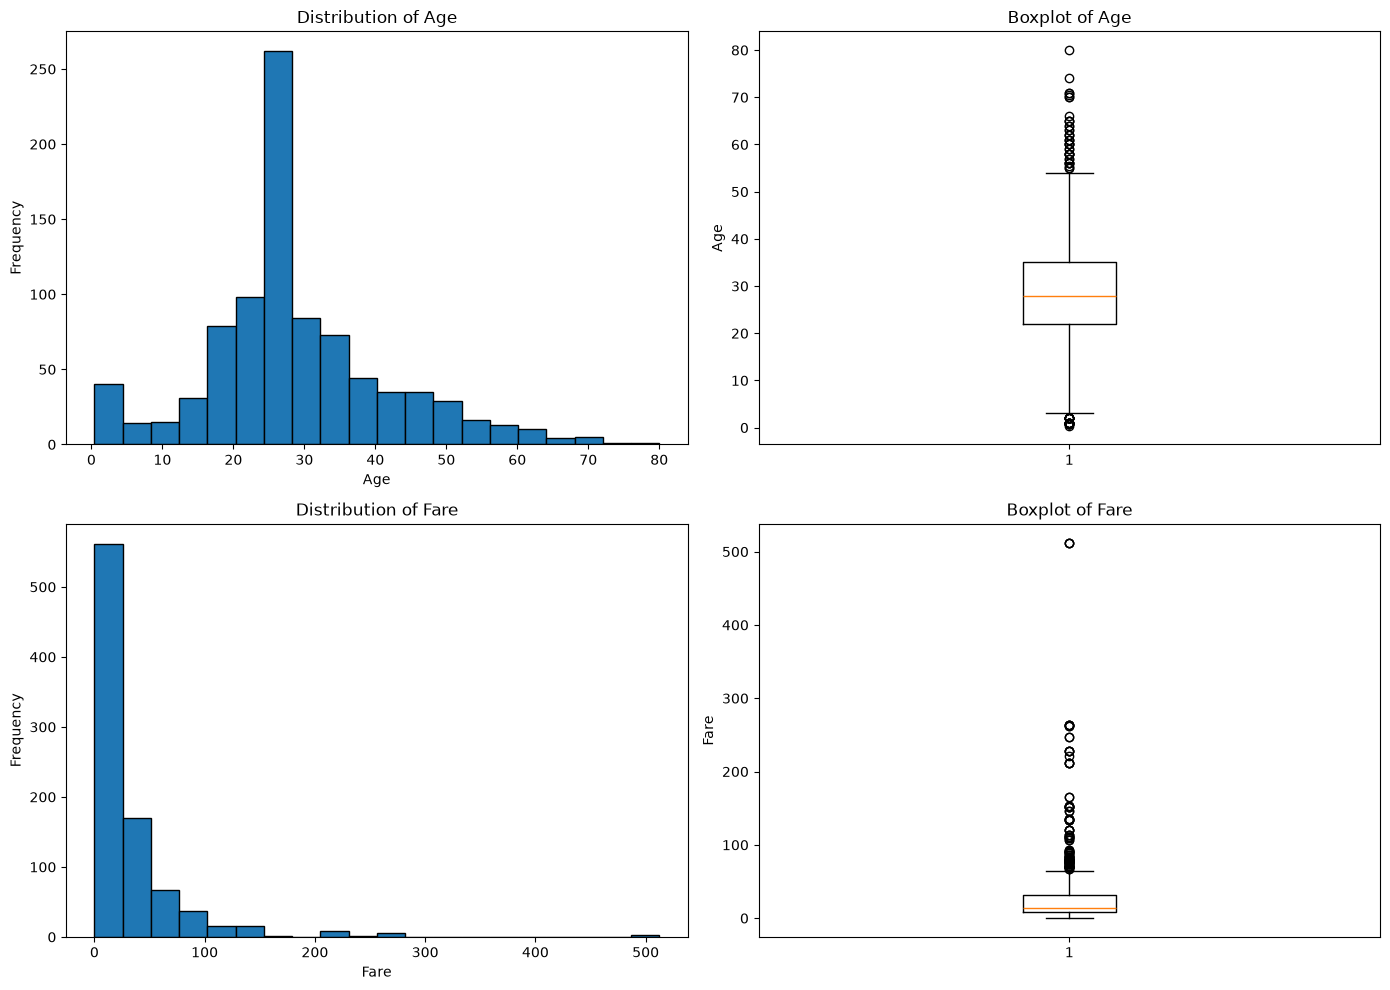

=== AGE IQR OUTLIER ANALYSIS ===
Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower Bound: 2.5
Upper Bound: 54.5
Outlier Count: 65

=== FARE IQR OUTLIER ANALYSIS ===
Q1: 7.8958
Q3: 31.0
IQR: 23.1042
Lower Bound: -26.7605
Upper Bound: 65.6563
Outlier Count: 114


In [5]:
import matplotlib.pyplot as plt

# Univariate analysis for age and fare

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age histogram
axes[0, 0].hist(cleaned_df["age"], bins=20, edgecolor="black")
axes[0, 0].set_title("Distribution of Age")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Frequency")

# Age boxplot
axes[0, 1].boxplot(cleaned_df["age"], vert=True)
axes[0, 1].set_title("Boxplot of Age")
axes[0, 1].set_ylabel("Age")

# Fare histogram
axes[1, 0].hist(cleaned_df["fare"], bins=20, edgecolor="black")
axes[1, 0].set_title("Distribution of Fare")
axes[1, 0].set_xlabel("Fare")
axes[1, 0].set_ylabel("Frequency")

# Fare boxplot
axes[1, 1].boxplot(cleaned_df["fare"], vert=True)
axes[1, 1].set_title("Boxplot of Fare")
axes[1, 1].set_ylabel("Fare")

plt.tight_layout()
plt.show()


# IQR outlier calculation
def iqr_outlier_count(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = series[(series < lower_bound) | (series > upper_bound)]

    return q1, q3, iqr, lower_bound, upper_bound, len(outliers)


age_q1, age_q3, age_iqr, age_lower, age_upper, age_outliers = iqr_outlier_count(
    cleaned_df["age"]
)

fare_q1, fare_q3, fare_iqr, fare_lower, fare_upper, fare_outliers = iqr_outlier_count(
    cleaned_df["fare"]
)

print("=== AGE IQR OUTLIER ANALYSIS ===")
print("Q1:", age_q1)
print("Q3:", age_q3)
print("IQR:", age_iqr)
print("Lower Bound:", age_lower)
print("Upper Bound:", age_upper)
print("Outlier Count:", age_outliers)

print("\n=== FARE IQR OUTLIER ANALYSIS ===")
print("Q1:", fare_q1)
print("Q3:", fare_q3)
print("IQR:", fare_iqr)
print("Lower Bound:", fare_lower)
print("Upper Bound:", fare_upper)
print("Outlier Count:", fare_outliers)

In [7]:
# Fare central tendency and skewness

fare_mean = cleaned_df["fare"].mean()
fare_median = cleaned_df["fare"].median()
fare_mode = cleaned_df["fare"].mode()[0]
fare_skewness = cleaned_df["fare"].skew()

print("=== FARE STATISTICS ===")
print(f"Mean   : {fare_mean:.4f}")
print(f"Median : {fare_median:.4f}")
print(f"Mode   : {fare_mode:.4f}")
print(f"Skewness: {fare_skewness:.4f}")

print("\n=== COMPARISON ===")
if fare_mean > fare_median > fare_mode:
    print("Mean > Median > Mode, indicating a positively (right) skewed distribution.")
elif fare_mean > fare_median:
    print("Mean is greater than the median, indicating positive/right skewness.")
else:
    print("The ordering of mean, median, and mode does not show the typical positive-skew pattern.")

=== FARE STATISTICS ===
Mean   : 32.0967
Median : 14.4542
Mode   : 8.0500
Skewness: 4.8014

=== COMPARISON ===
Mean > Median > Mode, indicating a positively (right) skewed distribution.


## Fare Mean, Median, Mode and Skewness Interpretation

The mean fare is **32.0967**, while the median is **14.4542** and the mode is **8.0500**. The mean is substantially higher than both the median and mode, showing that a relatively small number of high-fare observations pull the average upward. The skewness value is **4.8014**, which indicates strong positive (right) skewness. Therefore, the median and mode provide a better representation of the typical fare than the mean because the mean is strongly influenced by extreme high-fare values.

In [8]:
# Bivariate survival-rate analysis

print("=== SURVIVAL RATE BY SEX ===")
survival_by_sex = cleaned_df.groupby("sex")["survived"].mean().mul(100).round(2)
display(survival_by_sex)

print("=== SURVIVAL RATE BY PCLASS ===")
survival_by_pclass = cleaned_df.groupby("pclass")["survived"].mean().mul(100).round(2)
display(survival_by_pclass)

print("=== SURVIVAL RATE BY SEX AND PCLASS ===")
survival_by_sex_pclass = (
    cleaned_df.groupby(["sex", "pclass"])["survived"]
    .mean()
    .mul(100)
    .round(2)
)

display(survival_by_sex_pclass)

=== SURVIVAL RATE BY SEX ===


sex
female    74.04
male      18.89
Name: survived, dtype: float64

=== SURVIVAL RATE BY PCLASS ===


pclass
1    62.62
2    47.28
3    24.24
Name: survived, dtype: float64

=== SURVIVAL RATE BY SEX AND PCLASS ===


sex     pclass
female  1         96.74
        2         92.11
        3         50.00
male    1         36.89
        2         15.74
        3         13.54
Name: survived, dtype: float64

## Bivariate Survival Analysis Interpretation

Survival rates differed substantially by sex and passenger class. Female passengers had a survival rate of 74.04%, compared with 18.89% for male passengers. Survival also varied by passenger class, with rates of 62.62% for first class, 47.28% for second class, and 24.24% for third class.

The combined analysis of sex and passenger class shows that female first-class passengers had the highest observed survival rate at 96.74%, followed by female second-class passengers at 92.11%. Female third-class passengers had a survival rate of 50.00%, while male passengers had lower survival rates across all three classes, ranging from 36.89% in first class to 13.54% in third class. These results show that both sex and passenger class are strongly associated with survival in this dataset.

=== 6-COLUMN CORRELATION MATRIX ===


,survived,pclass,age,sibsp,parch,fare
survived,1.0000,-0.3355,-0.0698,-0.0340,0.0832,0.2553
pclass,-0.3355,1.0000,-0.3365,0.0817,0.0168,-0.5482
age,-0.0698,-0.3365,1.0000,-0.2325,-0.1715,0.0937
sibsp,-0.0340,0.0817,-0.2325,1.0000,0.4145,0.1609
parch,0.0832,0.0168,-0.1715,0.4145,1.0000,0.2175
fare,0.2553,-0.5482,0.0937,0.1609,0.2175,1.0000


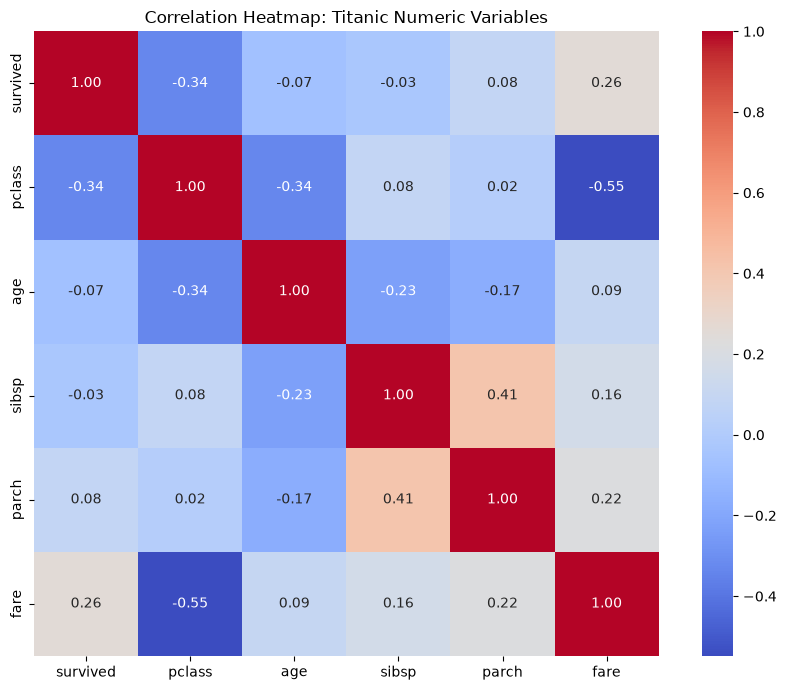

In [9]:
# Correlation analysis using the exact six required columns

correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = cleaned_df[correlation_columns].corr()

print("=== 6-COLUMN CORRELATION MATRIX ===")
display(corr_matrix.round(4))

# Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Correlation Heatmap: Titanic Numeric Variables")
plt.tight_layout()
plt.show()

## Correlation Analysis Interpretation

The two strongest absolute off-diagonal correlations are between `pclass` and `fare` (r = -0.5482) and between `sibsp` and `parch` (r = 0.4145).

The correlation between `pclass` and `fare` is moderately negative, indicating that higher numerical passenger-class values are generally associated with lower fares. Since the Titanic dataset codes first class as 1 and third class as 3, this relationship is consistent with higher fares being more common among higher-class passengers.

The correlation between `sibsp` and `parch` is moderately positive, indicating that passengers traveling with more siblings/spouses also tended to travel with more parents/children. These correlations describe relationships between variables and do not by themselves establish causation.

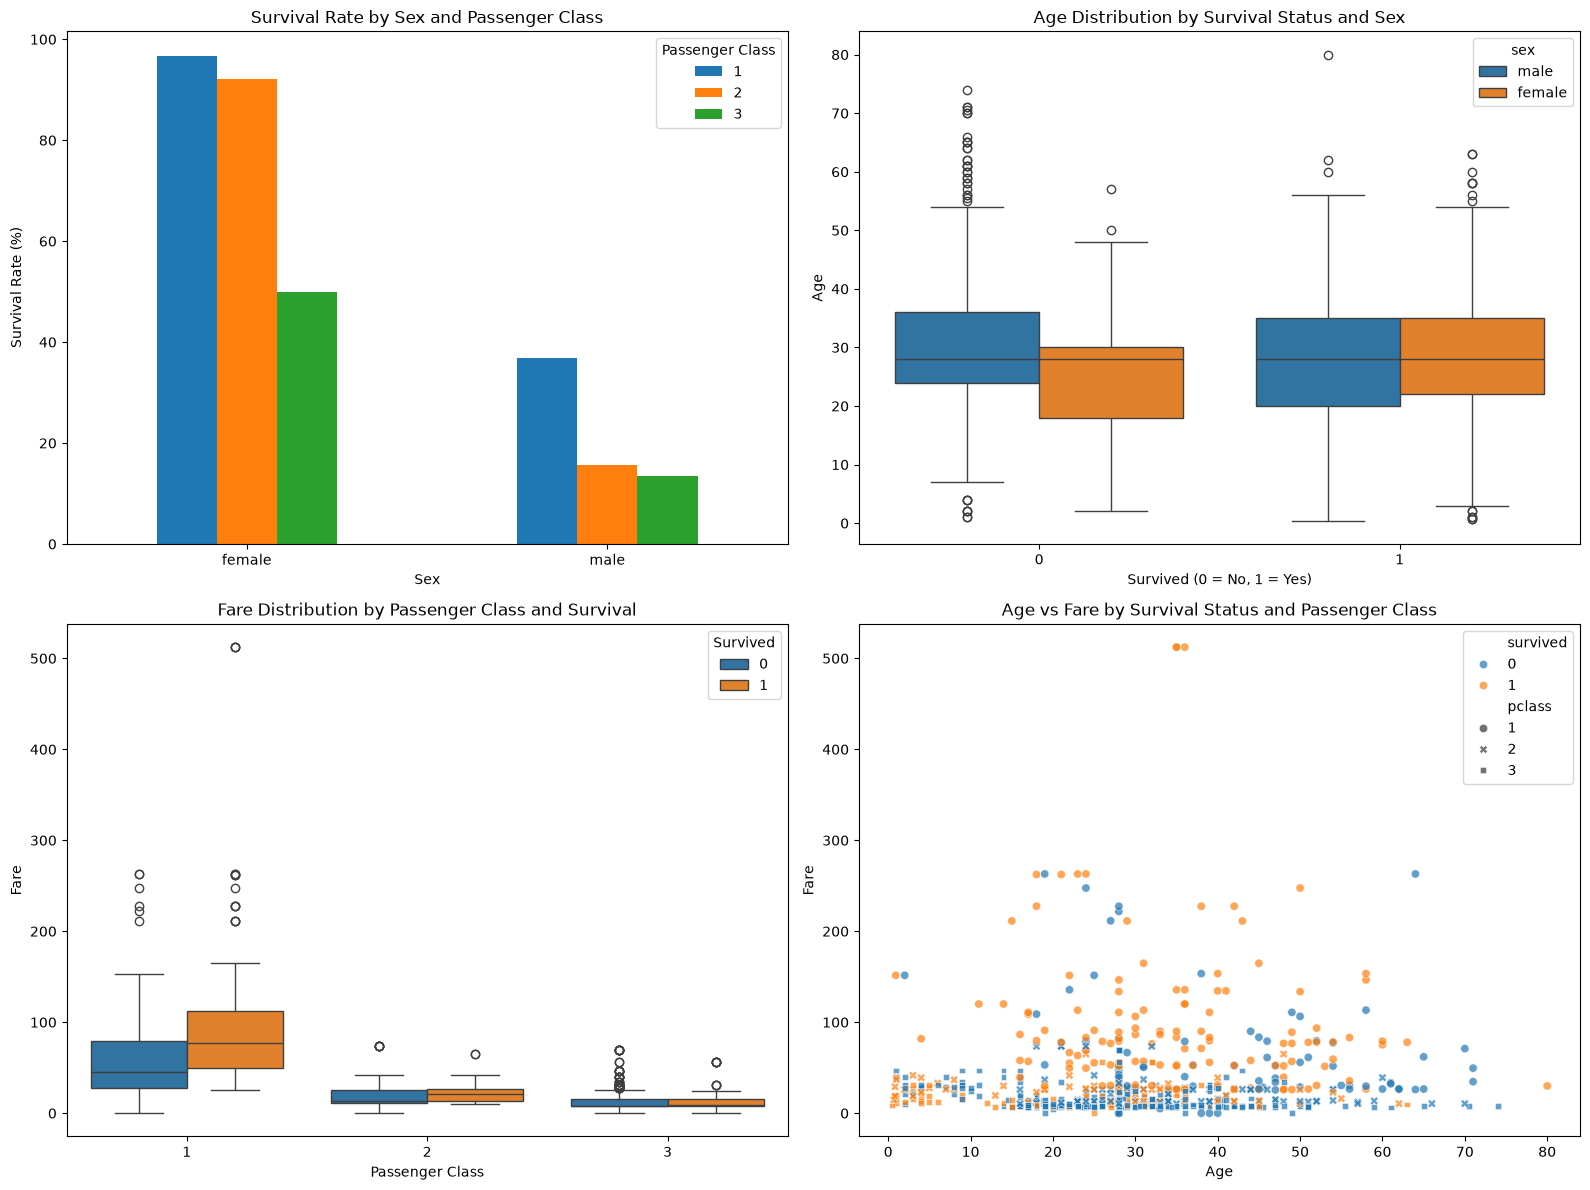

In [10]:
# Multivariate Analysis - 4 Charts

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Survival rate by sex and passenger class
survival_pivot = (
    cleaned_df.groupby(["sex", "pclass"])["survived"]
    .mean()
    .mul(100)
    .unstack()
)

survival_pivot.plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Survival Rate by Sex and Passenger Class")
axes[0, 0].set_xlabel("Sex")
axes[0, 0].set_ylabel("Survival Rate (%)")
axes[0, 0].legend(title="Passenger Class")
axes[0, 0].tick_params(axis="x", rotation=0)


# Chart 2: Age distribution by survival and sex
sns.boxplot(
    data=cleaned_df,
    x="survived",
    y="age",
    hue="sex",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Age Distribution by Survival Status and Sex")
axes[0, 1].set_xlabel("Survived (0 = No, 1 = Yes)")
axes[0, 1].set_ylabel("Age")


# Chart 3: Fare distribution by survival and passenger class
sns.boxplot(
    data=cleaned_df,
    x="pclass",
    y="fare",
    hue="survived",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Fare Distribution by Passenger Class and Survival")
axes[1, 0].set_xlabel("Passenger Class")
axes[1, 0].set_ylabel("Fare")
axes[1, 0].legend(title="Survived")


# Chart 4: Age vs fare by survival status
sns.scatterplot(
    data=cleaned_df,
    x="age",
    y="fare",
    hue="survived",
    style="pclass",
    alpha=0.7,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Age vs Fare by Survival Status and Passenger Class")
axes[1, 1].set_xlabel("Age")
axes[1, 1].set_ylabel("Fare")

plt.tight_layout()
plt.show()

## Multivariate Analysis Interpretations

### 1. Survival Rate by Sex and Passenger Class

Survival rates were substantially higher for female passengers than male passengers across all passenger classes. Female first- and second-class passengers had survival rates above 90%, while female third-class passengers had a survival rate of 50.00%. Male survival rates were considerably lower, particularly in second and third class.

### 2. Age Distribution by Survival Status and Sex

The age distributions show differences between survivors and non-survivors across sex groups. Female survivors had a somewhat higher central age than female non-survivors, while the male groups show substantial overlap in their age distributions. Several age outliers are visible, particularly among male passengers.

### 3. Fare Distribution by Passenger Class and Survival

First-class passengers had substantially higher fares than second- and third-class passengers. Within first class, the fare distribution for survivors is generally higher than that of non-survivors, while the differences are smaller in the lower classes. The chart also shows several high-fare outliers, particularly among first-class passengers.

### 4. Age vs Fare by Survival Status and Passenger Class

The scatter plot shows that most passengers paid relatively low fares, while a smaller number of passengers paid substantially higher fares. Higher fares are concentrated more strongly among first-class passengers, and the plot shows considerable overlap between survivors and non-survivors across age ranges. Passenger class therefore provides useful additional context when examining the relationship between age, fare, and survival.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Select age and fare from the full cleaned dataset
standardization_data = cleaned_df[["age", "fare"]].copy()

print("=== BEFORE STANDARDIZATION ===")
print(standardization_data.describe().loc[["mean", "std"]])

# Z-score standardization
scaler_eda = StandardScaler()
standardized_values = scaler_eda.fit_transform(standardization_data)

standardized_df = pd.DataFrame(
    standardized_values,
    columns=["age_standardized", "fare_standardized"],
    index=cleaned_df.index
)

print("\n=== AFTER STANDARDIZATION ===")
print(standardized_df.describe().loc[["mean", "std"]])

print("\n=== STANDARDIZED DATA SAMPLE ===")
display(standardized_df.head())

=== BEFORE STANDARDIZATION ===
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

=== AFTER STANDARDIZATION ===
      age_standardized  fare_standardized
mean      2.717486e-16       1.398706e-16
std       1.000563e+00       1.000563e+00

=== STANDARDIZED DATA SAMPLE ===


,age_standardized,fare_standardized
0,-0.563674,-0.500240
1,0.669217,0.788947
2,-0.255451,-0.486650
3,0.438050,0.422861
4,0.438050,-0.484133


: 

## Age and Fare Standardization

Z-score standardization was applied to `age` and `fare` using the full cleaned dataset as an EDA sanity check. Before standardization, the mean age was 29.3152 and the mean fare was 32.0967.

After standardization, both variables had means effectively equal to zero (`2.71e-16` for age and `1.40e-16` for fare). The standard deviations were approximately 1 (`1.000563` for both variables when calculated using Pandas sample standard deviation), confirming that the standardization was successful.

These standardized variables are used only for EDA validation and will not be used as the modeling preprocessing pipeline. The modeling pipeline will independently fit preprocessing transformations on the training data only.

In [1]:
print("Kernel is working.")

Kernel is working.


In [1]:
print("Kernel is working.")

Kernel is working.
